In [1]:
import numpy as np
import os

import re

import glob

import matplotlib

import matplotlib.pyplot as plt
from matplotlib import cm, ticker
from matplotlib.ticker import LogLocator, LogFormatterSciNotation

from matplotlib.colors import LogNorm

In [11]:
from matplotlib.ticker import LogLocator

In [2]:
# alldat = {}
# files = glob.glob('./sweep6-31g/*_coeffs.txt')
# for f in files:
#     m = re.search(
#         r'_([-+]?\d*\.?\d+)_([-+]?\d*\.?\d+)_1_coeffs\.txt$',
#         f
#     )
#     freq, amp = map(float, m.groups())
#     coeffs = np.loadtxt(f,dtype=np.complex128,delimiter=',')
#     probs = np.abs(coeffs)**2
#     print(np.max(np.abs(probs.sum(axis=1) - 1)))
#     logp = np.zeros_like(probs)
#     np.log2(probs, out=logp, where=(probs > 0))
#     entropies = -(probs * logp).sum(axis=1)
#     maxent = entropies.max()
#     probs = np.mean(np.abs(coeffs)**2, axis=0)
#     p = probs[probs>0]
#     ent = -np.sum(p * np.log2(p))
#     if (freq,amp) not in alldat:
#         alldat[(freq, amp)] = np.array([ent, maxent])
#     else:
#         print("Key collision!")

In [3]:
ent = np.zeros((40, 40))
maxent = np.zeros((40, 40))

In [4]:
start = 1e-4
end   = 2e-3
ratio = np.exp((np.log(end/start))/39)
intensity = start * ratio**np.arange(40)
start = 1e-3
end   = 5e-2
ratio = np.exp((np.log(end/start))/39)
freq = start * ratio**np.arange(40)

In [5]:
for i in range(40):
    for j in range(40):
        fname = f"./sweep6-31g/fci_h2_6-31g_0.050000_{freq[i]:.6f}_{intensity[j]:.6f}_1_coeffs.txt"
        coeffs = np.loadtxt(fname,dtype=np.complex128,delimiter=',')
        probs = np.abs(coeffs)**2
        print(np.max(np.abs(probs.sum(axis=1) - 1)))
        logp = np.zeros_like(probs)
        np.log2(probs, out=logp, where=(probs > 0))
        entropies = -(probs * logp).sum(axis=1)
        maxent[i,j] = entropies.max()
        probs = np.mean(np.abs(coeffs)**2, axis=0)
        p = probs[probs>0]
        ent[i,j] = -np.sum(p * np.log2(p))
        

1.3825524292077063e-06
1.392027854207889e-06
1.4025473050738313e-06
1.3948837682686843e-06
1.3899877000511651e-06
1.3979203802305662e-06
1.3957702743594425e-06
1.3963583819220915e-06
1.3964327654214514e-06
1.3859048714204292e-06
1.381848796722096e-06
1.3939893110936907e-06
1.3909833711522879e-06
1.3808360680434006e-06
1.3966126142239688e-06
1.3902006361643515e-06
1.3828347634747828e-06
1.4037115158016533e-06
1.3970586683065278e-06
1.39692569600669e-06
1.4020604888198562e-06
1.4002061669016186e-06
1.3890158472307235e-06
1.3755276888627321e-06
1.4094866875868917e-06
1.3905233295918862e-06
1.401081543450644e-06
1.3787935759790315e-06
1.3929459792283438e-06
1.3904249981377959e-06
1.393724397891205e-06
1.398861971813048e-06
1.3775602396570719e-06
1.3749144767150057e-06
1.3967754689536704e-06
1.4054123442797106e-06
1.4007451104580682e-06
1.4035234018328069e-06
1.3968428895783092e-06
1.3915699590416608e-06
1.3986266720333873e-06
1.3961233470416445e-06
1.3890705220509503e-06
1.3845016223479334

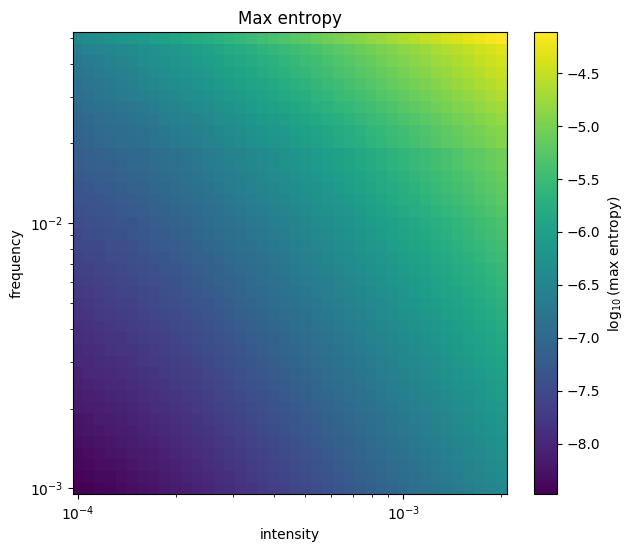

In [6]:

# freq, intensity, alldata as before
Z = np.log10(np.expand_dims(freq, 1)*maxent)

# Build 2D grid edges for pcolormesh.
# For 1D arrays x of length N, create edges of length N+1 by geometric mean for log-spaced data:
def edges_from_centers(centers):
    # geometric edges for log-spaced centers
    edges = np.empty(len(centers) + 1)
    edges[1:-1] = np.sqrt(centers[:-1] * centers[1:])
    edges[0] = centers[0]**2 / edges[1]
    edges[-1] = centers[-1]**2 / edges[-2]
    return edges

x_edges = edges_from_centers(intensity)   # columns -> x
y_edges = edges_from_centers(freq)        # rows -> y

plt.figure(figsize=(7,6))
# Note: pcolormesh expects Z shape (Ny, Nx) where Ny = len(y_centers), Nx = len(x_centers)
mesh = plt.pcolormesh(x_edges, y_edges, Z, shading='auto', cmap='viridis')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('intensity')
plt.ylabel('frequency')
plt.title('Max entropy')
cbar = plt.colorbar(mesh)
cbar.set_label(r'$\log_{10}$(max entropy)')

plt.gca().xaxis.set_major_locator(LogLocator(base=10))
plt.gca().yaxis.set_major_locator(LogLocator(base=10))
plt.gca().xaxis.set_major_formatter(LogFormatterSciNotation())
plt.gca().yaxis.set_major_formatter(LogFormatterSciNotation())

plt.savefig('maxent50_6-31g.pdf', bbox_inches='tight')
plt.show()
plt.close('all')


In [7]:
path = './sweep6-31g/'
delay = 50
alldata = np.zeros((40, 40))
for i in range(40):
    for j in range(40):
        freqstr = f"{freq[i]:.6f}"
        istr = f"{intensity[j]:.6f}"
        target_file='fci_h2_6-31g_0.050000_'+str(delay)+'_'+freqstr+'_'+istr+'_1.txt'
        f = np.loadtxt(path + target_file, skiprows=2, delimiter=',')
        alldata[i, j] = f[1]

In [8]:
intensity

array([0.0001    , 0.00010798, 0.00011661, 0.00012592, 0.00013597,
       0.00014682, 0.00015855, 0.00017121, 0.00018487, 0.00019964,
       0.00021557, 0.00023279, 0.00025137, 0.00027144, 0.00029311,
       0.00031652, 0.00034179, 0.00036908, 0.00039854, 0.00043036,
       0.00046472, 0.00050183, 0.00054189, 0.00058516, 0.00063188,
       0.00068233, 0.00073681, 0.00079563, 0.00085916, 0.00092775,
       0.00100183, 0.00108181, 0.00116819, 0.00126145, 0.00136217,
       0.00147093, 0.00158837, 0.00171518, 0.00185212, 0.002     ])

In [61]:
# x = (np.expand_dims(freq,1)*maxent).ravel()
x = maxent.ravel()
y = alldata.ravel()

intensity_tiled = np.tile(intensity, 40)
def intensity_to_size(I):
    logI = np.log10(I)
    return 1 + 10 * (
        (logI - np.log10(intensity_tiled.min()))
        / (np.log10(intensity_tiled.max()) - np.log10(intensity_tiled.min()))
    )

sizes = intensity_to_size(intensity_tiled)

plt.figure(figsize=(6,5))
# plt.scatter( x, y, marker='.', c=np.log10(intens), cmap='plasma' )
sc = plt.scatter( x, y, c=np.repeat(freq,40), s=sizes, cmap='rainbow', norm=LogNorm( vmin=np.min(freq), vmax=np.max(freq) ) )

cbar = plt.colorbar(sc)
ticks = [1e-3, 2e-3, 5e-3, 1e-2, 2e-2, 3e-2, 5e-2]
cbar.set_ticks(ticks)
cbar.set_ticklabels([r'$10^{-3}$',
                     r'$2 \times 10^{-3}$',
                     r'$5 \times 10^{-3}$',
                     r'$10^{-2}$',
                     r'$2 \times 10^{-2}$',
                     r'$3 \times 10^{-2}$',
                     r'$5 \times 10^{-2}$'])
cbar.set_label(r'frequency 1/(a.u.)')

levels = [1e-4, 2e-4, 5e-4, 1e-3, 2e-3]

handles = [
    plt.scatter([], [], s=intensity_to_size(v), color='gray')
    for v in levels
]

plt.legend(
    handles,
    [f'{v:.4f}' for v in levels],
    title=r'$E_0$ (a.u.)'
)


plt.xscale('log')
plt.yscale('log')
plt.xlabel('max entropy (bits)')
plt.ylabel('mean absolute error in 1-RDMs')
plt.grid(True, color='lightgrey', linewidth=0.1)
plt.tight_layout()
plt.savefig('maxent.pdf')
plt.close('all')

In [97]:
intensity

array([0.0001    , 0.00010798, 0.00011661, 0.00012592, 0.00013597,
       0.00014682, 0.00015855, 0.00017121, 0.00018487, 0.00019964,
       0.00021557, 0.00023279, 0.00025137, 0.00027144, 0.00029311,
       0.00031652, 0.00034179, 0.00036908, 0.00039854, 0.00043036,
       0.00046472, 0.00050183, 0.00054189, 0.00058516, 0.00063188,
       0.00068233, 0.00073681, 0.00079563, 0.00085916, 0.00092775,
       0.00100183, 0.00108181, 0.00116819, 0.00126145, 0.00136217,
       0.00147093, 0.00158837, 0.00171518, 0.00185212, 0.002     ])

In [68]:
print(x.shape, y.shape, intens.shape)
print(np.min(x), np.max(x))
print(np.min(y), np.max(y))
print(np.sum(x > 0), np.sum(y > 0))

(1600,) (1600,) (1600,)
3.330025199527048e-09 7.683228022250874e-05
1.1117084688716293e-05 0.004717348967619339
1600 1600


In [52]:
freq_rep = np.repeat(freq, 40)

for f in np.unique(freq_rep):
    mask = np.isclose(freq_rep, f)

    m, b = np.polyfit(
        np.log10(x[mask]),
        np.log10(y[mask]),
        1
    )

    print(f"{f:.4e}: slope={m:.3f}, intercept={b:.3f}")

1.0000e-03: slope=0.610, intercept=-1.319
1.1055e-03: slope=0.609, intercept=-1.358
1.2222e-03: slope=0.608, intercept=-1.392
1.3511e-03: slope=0.608, intercept=-1.424
1.4937e-03: slope=0.608, intercept=-1.447
1.6513e-03: slope=0.607, intercept=-1.470
1.8255e-03: slope=0.606, intercept=-1.498
2.0181e-03: slope=0.607, intercept=-1.489
2.2310e-03: slope=0.606, intercept=-1.537
2.4664e-03: slope=0.605, intercept=-1.498
2.7267e-03: slope=0.606, intercept=-1.519
3.0144e-03: slope=0.604, intercept=-1.539
3.3324e-03: slope=0.602, intercept=-1.528
3.6840e-03: slope=0.601, intercept=-1.569
4.0727e-03: slope=0.601, intercept=-1.486
4.5025e-03: slope=0.601, intercept=-1.431
4.9775e-03: slope=0.597, intercept=-1.457
5.5027e-03: slope=0.597, intercept=-1.497
6.0833e-03: slope=0.598, intercept=-1.359
6.7252e-03: slope=0.599, intercept=-1.419
7.4348e-03: slope=0.601, intercept=-1.232
8.2192e-03: slope=0.600, intercept=-1.318
9.0864e-03: slope=0.600, intercept=-1.225
1.0045e-02: slope=0.604, intercept

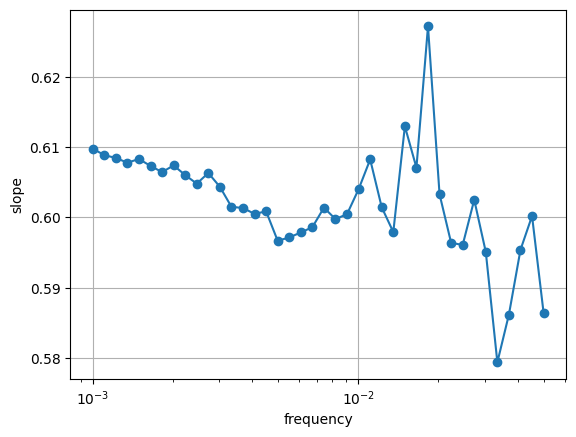

In [53]:
slopes = []
intercepts = []

freq_rep = np.repeat(freq,40)

for f in freq:
    mask = freq_rep == f

    m, b = np.polyfit(
        np.log10(x[mask]),
        np.log10(y[mask]),
        1
    )

    slopes.append(m)
    intercepts.append(b)

plt.figure()
plt.semilogx(freq, slopes, 'o-')
plt.xlabel('frequency')
plt.ylabel('slope')
plt.grid(True)

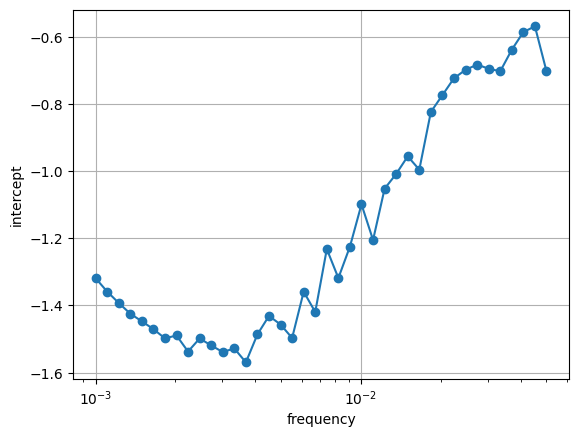

In [54]:
plt.figure()
plt.semilogx(freq, intercepts, 'o-')
plt.xlabel('frequency')
plt.ylabel('intercept')
plt.grid(True)

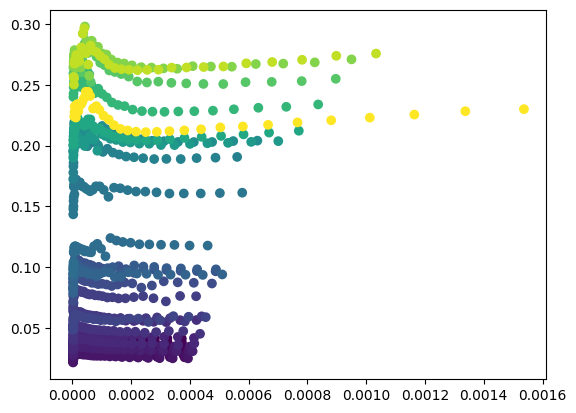

In [56]:
plt.scatter(
    x,
    y / x**0.6,
    c=np.repeat(freq,40)
)